# Test Diagram Rendering

This notebook verifies the PlantUML diagram rendering capabilities using the `planturl` wrapper function.

## Setup Cell
Since Jupyter Notebooks do not naturally define `__file__`, we mock it in this cell and change the working directory to the `aga` directory to ensure that relative paths (like `test_example/...`) resolve correctly and the requested code block runs unmodified.

In [1]:
# Compatibility Setup for Jupyter Notebook
import os
import sys
from pathlib import Path

# 1. Find the project root directory
PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "test_project" else Path(os.getcwd())

# 2. Mock __file__ so that Path(__file__).resolve().parent / "tools" evaluates to "aga/tools"
__file__ = str(PROJECT_ROOT / "aga" / "dummy_script.py")

# 3. Change directory to "aga" so that the relative path "test_example/..." is found
os.chdir(PROJECT_ROOT / "aga")

print(f"Jupyter Notebook Setup Complete!")
print(f"Current working directory changed to: {os.getcwd()}")
print(f"Mocked __file__ set to: {__file__}")

Jupyter Notebook Setup Complete!
Current working directory changed to: /home/delatom/I-Architect-3cf20c60d77417e9febe099eeb91bc78227ce89f/aga
Mocked __file__ set to: /home/delatom/I-Architect-3cf20c60d77417e9febe099eeb91bc78227ce89f/aga/dummy_script.py


## User Code Block
The code block below runs exactly as requested to render the C4 model diagram.

In [ ]:
import sys
from pathlib import Path

# Add the tools directory to sys.path if it is not already there
# (Assuming your script is in the root directory)
tools_dir = Path(__file__).resolve().parent / "tools"
if str(tools_dir) not in sys.path:
    sys.path.insert(0, str(tools_dir))

# Import the rendering function and the custom exception
from planturl_render import render_plantuml, PlantURLError

# Define paths
input_file = "test_example/Sequencediagram.puml"
output_file = "output_diagram.png"

try:
    # Render the plantuml file
    rendered_path = render_plantuml(
        input_path=input_file,
        output_path=output_file,
        output_type="png"
    )
    print(f"Success! Saved to: {rendered_path}")

except PlantURLError as e:
    print(f"Error rendering PlantUML diagram! Details:\n{e}")
except FileNotFoundError as e:
    print(f"File path error: {e}")

Success! Saved to: /home/delatom/I-Architect-3cf20c60d77417e9febe099eeb91bc78227ce89f/aga/output_diagram.png


## Display Rendered Output
Inspect the rendered C4 container diagram.

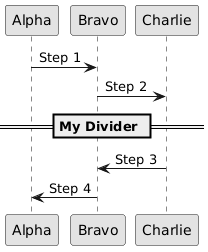

In [3]:
from IPython.display import display, Image
if Path(output_file).exists():
    display(Image(filename=output_file))
else:
    print("Rendered output not found!")